# Single Run Analysis

Point `RUN_DIR` at one run folder containing:
- `summary.json`
- `history.csv`
- `step_history.csv`

This notebook plots only:
- train loss and validation loss over epochs
- train loss and validation loss over steps
- train accuracy and validation accuracy over epochs
- train accuracy over steps, with best validation accuracy marked
- epoch seconds over epochs
- validation improved over epochs


In [28]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise ImportError(
        'This notebook needs matplotlib in the active kernel. Install it with something like `pip install matplotlib seaborn pandas`.'
    ) from exc

import pandas as pd

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError(
        'This notebook uses seaborn for plotting. Install it with something like `pip install seaborn` in the active kernel.'
    ) from exc

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 120)

RUN_DIR = Path(
    '/home/pkunwar/characterize_ttlora/phases/ttlora_core_count_study/runs/cola_contraction/'
    'ttcore_roberta_mrpc_cola_core_study_cola_contraction_cores10_rank6_lr2e-03_seed647761'
).resolve()

RUN_DIR


PosixPath('/home/pkunwar/characterize_ttlora/phases/ttlora_core_count_study/runs/cola_contraction/ttcore_roberta_mrpc_cola_core_study_cola_contraction_cores10_rank6_lr2e-03_seed647761')

In [29]:
def _coerce_bool(value: Any) -> Any:
    if isinstance(value, bool):
        return value
    if isinstance(value, str):
        lowered = value.strip().lower()
        if lowered == 'true':
            return True
        if lowered == 'false':
            return False
    return value


def _coerce_scalar(value: Any) -> Any:
    value = _coerce_bool(value)
    if value is None or isinstance(value, (bool, int, float, dict, list)):
        return value
    text = str(value).strip()
    if text == '' or text.lower() in {'none', 'null', 'nan'}:
        return None
    try:
        if text.isdigit() or (text.startswith('-') and text[1:].isdigit()):
            return int(text)
        return float(text)
    except ValueError:
        return value


def _coerce_frame(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    for column in frame.columns:
        frame[column] = frame[column].map(_coerce_scalar)
    return frame


def load_run_artifacts(run_dir: Path) -> tuple[dict[str, Any], pd.DataFrame, pd.DataFrame]:
    run_dir = Path(run_dir).expanduser().resolve()
    summary_path = run_dir / 'summary.json'
    history_path = run_dir / 'history.csv'
    step_history_path = run_dir / 'step_history.csv'

    missing = [path.name for path in [summary_path, history_path, step_history_path] if not path.exists()]
    if missing:
        raise FileNotFoundError(f'Missing run artifacts in {run_dir}: {missing}')

    summary = json.loads(summary_path.read_text())
    history_df = _coerce_frame(pd.read_csv(history_path))
    step_history_df = _coerce_frame(pd.read_csv(step_history_path))
    return summary, history_df, step_history_df


def infer_train_accuracy_column(frame: pd.DataFrame) -> str | None:
    for candidate in ['train_accuracy', 'train_token_accuracy']:
        if candidate in frame.columns:
            return candidate
    return None


def infer_validation_accuracy_column(frame: pd.DataFrame, summary: dict[str, Any]) -> str | None:
    for candidate in ['validation_accuracy', 'validation_token_accuracy']:
        if candidate in frame.columns:
            return candidate
    if summary.get('best_validation_accuracy') is not None:
        return 'validation_accuracy'
    if summary.get('best_validation_token_accuracy') is not None:
        return 'validation_token_accuracy'
    return None


def best_validation_value(summary: dict[str, Any], validation_col: str | None) -> float | None:
    if validation_col == 'validation_accuracy':
        return summary.get('best_validation_accuracy')
    if validation_col == 'validation_token_accuracy':
        return summary.get('best_validation_token_accuracy')
    return None


In [30]:
summary, history_df, step_history_df = load_run_artifacts(RUN_DIR)

train_acc_epoch_col = infer_train_accuracy_column(history_df)
train_acc_step_col = infer_train_accuracy_column(step_history_df)
val_acc_col = infer_validation_accuracy_column(history_df, summary)
best_val_acc = best_validation_value(summary, val_acc_col)
best_epoch = summary.get('best_epoch')

overview = {
    'run_name': RUN_DIR.name,
    'dataset_name': summary.get('dataset_name'),
    'task_type': summary.get('task_type'),
    'ttlora_variant': summary.get('ttlora_variant'),
    'best_epoch': best_epoch,
    'best_validation_loss': summary.get('best_validation_loss'),
    'best_validation_accuracy': summary.get('best_validation_accuracy'),
    'best_validation_token_accuracy': summary.get('best_validation_token_accuracy'),
    'epochs_ran': summary.get('epochs_ran'),
}

display(pd.Series(overview, name='value').to_frame())
display(history_df.head())
display(step_history_df.head())


,value
run_name,ttcore_roberta_mrpc_cola_core_study_cola_contraction_cores10_rank6_lr2e-03_seed647761
dataset_name,cola
task_type,None
ttlora_variant,contraction
best_epoch,1
best_validation_loss,None
best_validation_accuracy,0.691275
best_validation_token_accuracy,None
epochs_ran,200


,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy,avg_grad_norm,max_grad_norm,min_grad_norm,clipped_step_fraction,clipped_steps,learning_rate,epoch_seconds,peak_memory_gb,validation_improved,best_validation_accuracy_so_far,epochs_since_improvement
0,1,0.620105,0.704245,0.618297,0.691275,0.137519,0.596293,0.000059,0.0,0,0.002,18.165931,1.337297,True,0.691275,0
1,2,0.608922,0.704362,0.618868,0.691275,0.097522,0.222178,0.047982,0.0,0,0.002,16.358016,1.337297,False,0.691275,1
2,3,0.609977,0.704362,0.618082,0.691275,0.084103,0.210121,0.046123,0.0,0,0.002,16.449841,1.337297,False,0.691275,2
3,4,0.608808,0.704362,0.620868,0.691275,0.076718,0.191142,0.039904,0.0,0,0.002,16.308968,1.337297,False,0.691275,3
4,5,0.611331,0.704362,0.619115,0.691275,0.077949,0.200802,0.040735,0.0,0,0.002,16.485351,1.337297,False,0.691275,4


,epoch,optimizer_step,optimizer_step_in_epoch,micro_step_end,train_loss,train_accuracy,grad_norm_pre_clip,clipping_triggered,learning_rate,examples_seen_epoch,elapsed_seconds
0,1,1,1,1,0.664169,0.68750,0.000084,False,0.002,32,0.327245
1,1,2,2,2,0.676281,0.59375,0.000080,False,0.002,64,0.400002
2,1,3,3,3,0.684670,0.65625,0.000109,False,0.002,96,0.469294
3,1,4,4,4,0.635269,0.84375,0.000266,False,0.002,128,0.538777
4,1,5,5,5,0.694248,0.50000,0.000059,False,0.002,160,0.610266


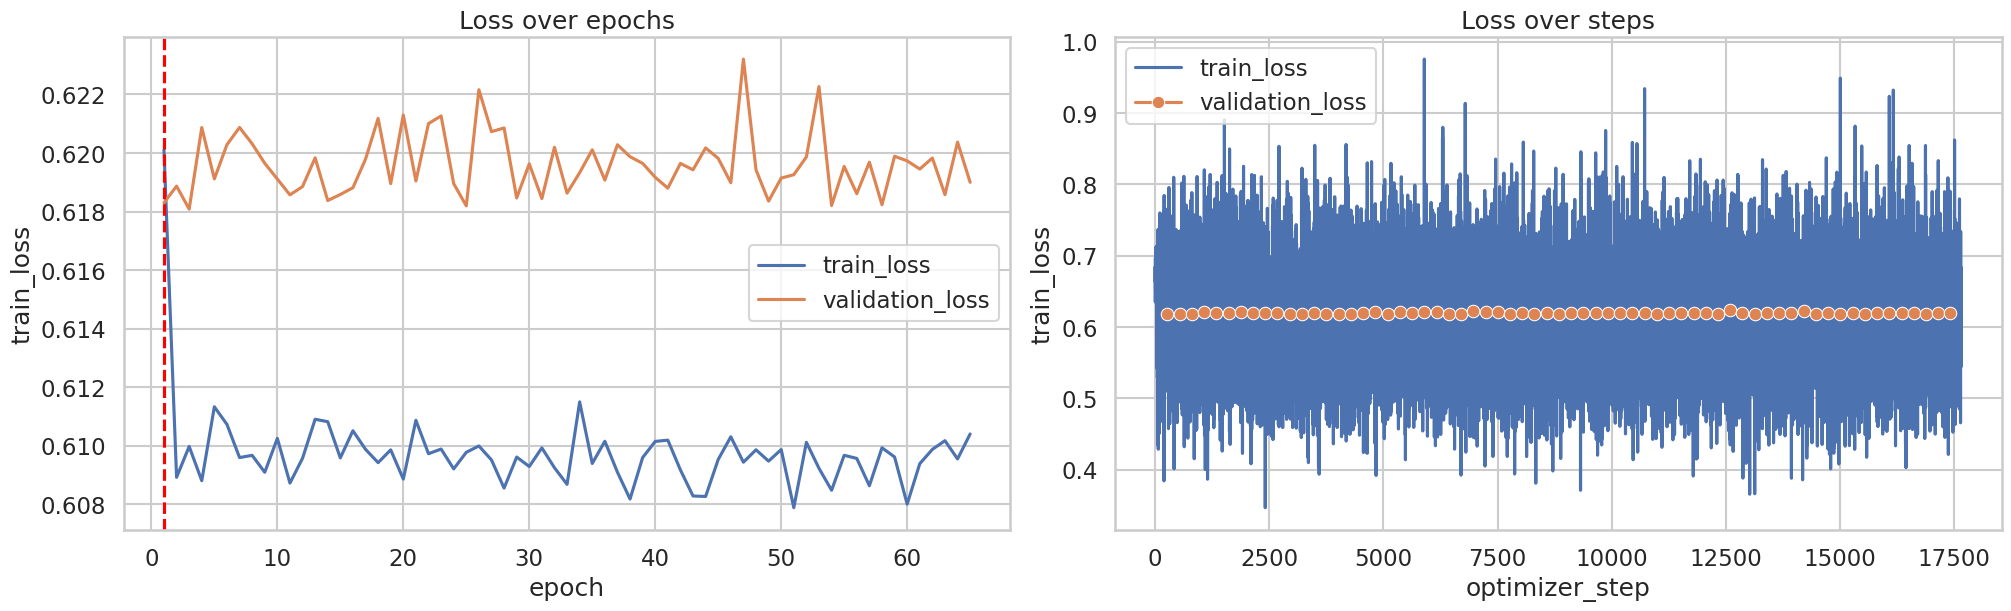

In [31]:
# Loss over epochs and steps
fig, axes = plt.subplots(1, 2, figsize=(20, 6), constrained_layout=True)

sns.lineplot(data=history_df, x='epoch', y='train_loss', ax=axes[0], label='train_loss')
if 'validation_loss' in history_df.columns:
    sns.lineplot(data=history_df, x='epoch', y='validation_loss', ax=axes[0], label='validation_loss')
if isinstance(best_epoch, (int, float)):
    axes[0].axvline(best_epoch, color='red', linestyle='--', label='best_epoch')
axes[0].set_title('Loss over epochs')

sns.lineplot(data=step_history_df, x='optimizer_step', y='train_loss', ax=axes[1], label='train_loss')
if 'validation_loss' in history_df.columns and isinstance(best_epoch, (int, float)):
    epoch_loss_df = history_df[['epoch', 'validation_loss']].dropna().copy()
    if not epoch_loss_df.empty:
        epoch_to_step = step_history_df.groupby('epoch', as_index=False)['optimizer_step'].max()
        val_step_df = epoch_loss_df.merge(epoch_to_step, on='epoch', how='inner')
        sns.lineplot(data=val_step_df, x='optimizer_step', y='validation_loss', ax=axes[1], marker='o', label='validation_loss')
axes[1].set_title('Loss over steps')

plt.show()


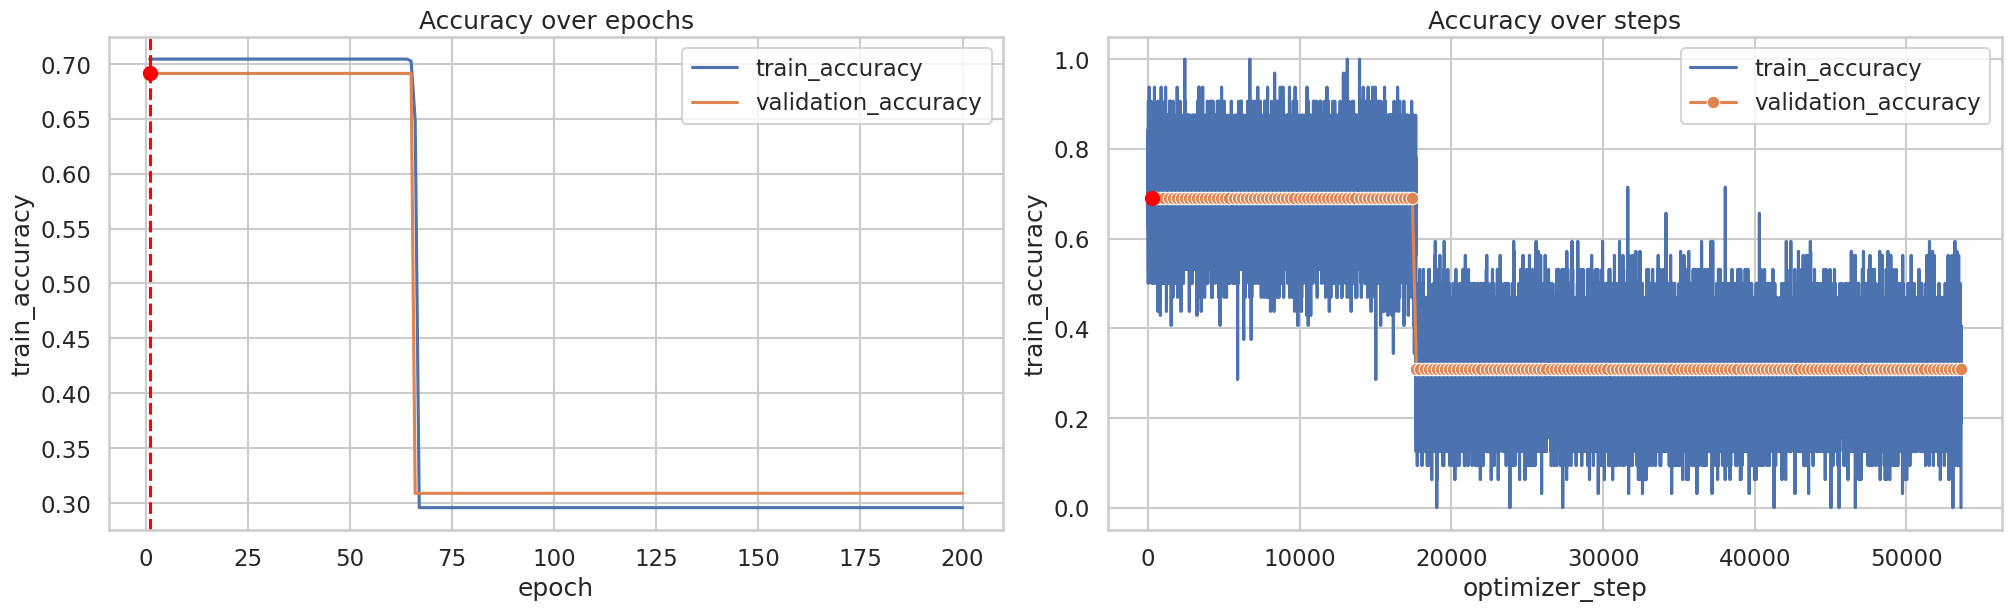

In [32]:
# Accuracy over epochs and steps, with best validation accuracy marked
fig, axes = plt.subplots(1, 2, figsize=(20, 6), constrained_layout=True)

if train_acc_epoch_col is not None:
    sns.lineplot(data=history_df, x='epoch', y=train_acc_epoch_col, ax=axes[0], label=f'{train_acc_epoch_col}')
if val_acc_col is not None and val_acc_col in history_df.columns:
    sns.lineplot(data=history_df, x='epoch', y=val_acc_col, ax=axes[0], label=f'{val_acc_col}')
if isinstance(best_epoch, (int, float)):
    axes[0].axvline(best_epoch, color='red', linestyle='--', label='best_epoch')
if best_val_acc is not None and isinstance(best_epoch, (int, float)):
    axes[0].scatter([best_epoch], [best_val_acc], color='red', s=90, zorder=5, label='best_val_acc')
axes[0].set_title('Accuracy over epochs')

if train_acc_step_col is not None:
    sns.lineplot(data=step_history_df, x='optimizer_step', y=train_acc_step_col, ax=axes[1], label=f'{train_acc_step_col}')
if val_acc_col is not None and val_acc_col in history_df.columns:
    epoch_acc_df = history_df[['epoch', val_acc_col]].dropna().copy()
    if not epoch_acc_df.empty:
        epoch_to_step = step_history_df.groupby('epoch', as_index=False)['optimizer_step'].max()
        val_step_df = epoch_acc_df.merge(epoch_to_step, on='epoch', how='inner')
        sns.lineplot(data=val_step_df, x='optimizer_step', y=val_acc_col, ax=axes[1], marker='o', label=f'{val_acc_col}')
        if best_val_acc is not None and isinstance(best_epoch, (int, float)):
            best_step_rows = val_step_df.loc[val_step_df['epoch'] == best_epoch]
            if not best_step_rows.empty:
                best_step = best_step_rows.iloc[0]['optimizer_step']
                axes[1].scatter([best_step], [best_val_acc], color='red', s=90, zorder=5, label='best_val_acc')
axes[1].set_title('Accuracy over steps')

plt.show()


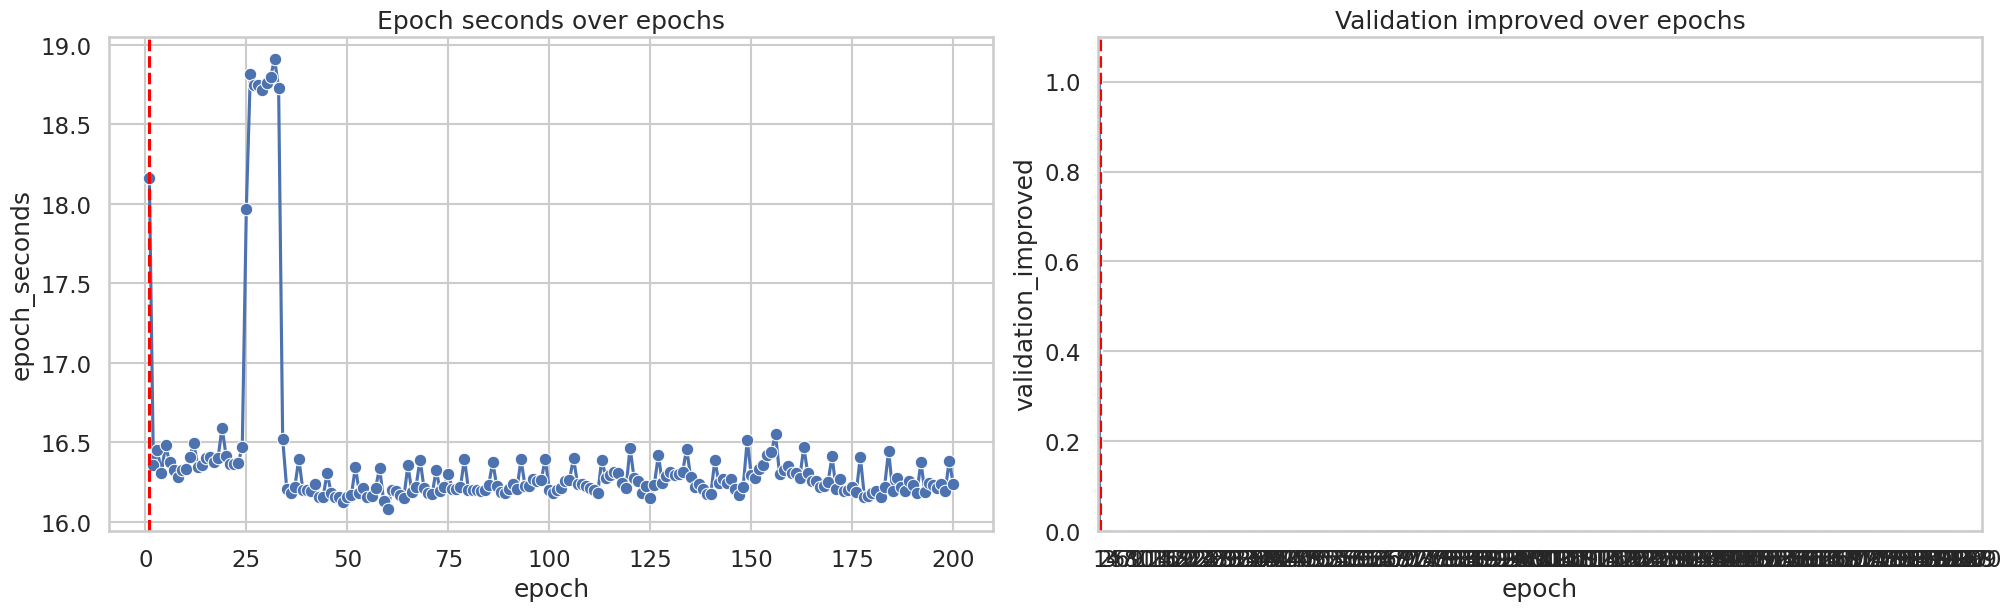

In [33]:
# Epoch seconds and validation improved over epochs
fig, axes = plt.subplots(1, 2, figsize=(20, 6), constrained_layout=True)

if 'epoch_seconds' in history_df.columns:
    sns.lineplot(data=history_df, x='epoch', y='epoch_seconds', ax=axes[0], marker='o')
    if isinstance(best_epoch, (int, float)):
        axes[0].axvline(best_epoch, color='red', linestyle='--', label='best_epoch')
    axes[0].set_title('Epoch seconds over epochs')
else:
    axes[0].axis('off')

if 'validation_improved' in history_df.columns:
    improved_df = history_df[['epoch', 'validation_improved']].copy()
    improved_df['validation_improved'] = improved_df['validation_improved'].astype(int)
    sns.barplot(data=improved_df, x='epoch', y='validation_improved', ax=axes[1], color='#4C78A8')
    if isinstance(best_epoch, (int, float)):
        axes[1].axvline(best_epoch - 1, color='red', linestyle='--', label='best_epoch')
    axes[1].set_ylim(0, 1.1)
    axes[1].set_title('Validation improved over epochs')
    axes[1].set_ylabel('validation_improved')
else:
    axes[1].axis('off')

plt.show()
